In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pprint
import os
import shutil
import time
import random

In [ ]:
import tensorflow_hub as hub

Detección de objetos

In [ ]:
detector_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
detector = hub.load(detector_url)

In [14]:
def cargarImagen(path):
    imagen = Image.open(path)
    imagen_numpy = np.array(imagen) # Convertir imagen a numpy
    imagen_tensor = tf.convert_to_tensor(imagen_numpy, dtype=tf.uint8) # Convertir imagen a tensor. Convertir a uint8 para que los valores sean 0-255
    imagen_tensor = tf.expand_dims(imagen_tensor, axis=0) # Añadir dimensión de batch. Con axis=0 se añade una dimensión al principio.
    print(imagen_tensor.shape)
    print(imagen_numpy.shape)
    return imagen_numpy, imagen_tensor

In [15]:
imagen_numpy, imagen_tensor = cargarImagen("img_car.png")

(1, 1214, 1200, 3)
(1214, 1200, 3)


In [19]:
imagen_numpy[0]

array([[ 90,  85,  82],
       [142, 137, 134],
       [151, 143, 141],
       ...,
       [ 99,  79,  70],
       [133, 111, 100],
       [188, 166, 155]], shape=(1200, 3), dtype=uint8)

In [23]:
imagen_tensor[0]

<tf.Tensor: shape=(1214, 1200, 3), dtype=uint8, numpy=
array([[[ 90,  85,  82],
        [142, 137, 134],
        [151, 143, 141],
        ...,
        [ 99,  79,  70],
        [133, 111, 100],
        [188, 166, 155]],

       [[ 91,  86,  83],
        [143, 138, 135],
        [152, 144, 142],
        ...,
        [102,  82,  73],
        [135, 113, 102],
        [189, 167, 156]],

       [[ 93,  85,  83],
        [145, 137, 135],
        [154, 146, 144],
        ...,
        [103,  83,  74],
        [135, 113, 102],
        [186, 164, 153]],

       ...,

       [[114, 114, 112],
        [118, 118, 116],
        [115, 115, 113],
        ...,
        [122, 121, 126],
        [124, 124, 126],
        [123, 123, 125]],

       [[114, 114, 114],
        [117, 117, 117],
        [115, 115, 115],
        ...,
        [121, 121, 123],
        [123, 123, 125],
        [123, 123, 125]],

       [[111, 111, 111],
        [116, 116, 116],
        [116, 116, 116],
        ...,
        [121, 121, 

In [16]:
detecciones = detector(imagen_tensor)

In [ ]:
# Estos valores son los que se obtienen de la detección

detecciones

{'detection_classes': <tf.Tensor: shape=(1, 100), dtype=float32, numpy=
 array([[ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  8.,  3.,  3.,  3.,  3.,
          3.,  3.,  8.,  3.,  3.,  3.,  3.,  3.,  8.,  3.,  3.,  3.,  3.,
          8.,  3.,  8.,  8.,  8.,  3.,  8.,  3.,  8.,  8.,  6.,  3.,  6.,
          8.,  3.,  8.,  3.,  1.,  3.,  8.,  8.,  1.,  3.,  1.,  8.,  6.,
          1.,  1.,  3.,  8.,  1.,  3.,  3.,  3.,  1.,  1., 10.,  3.,  3.,
          3.,  3.,  3.,  3.,  6.,  6.,  8.,  3.,  3.,  1.,  3.,  8.,  3.,
         10.,  3.,  3.,  3.,  1., 10.,  8.,  8.,  1.,  6.,  1.,  3., 10.,
          1.,  1.,  4.,  8., 15.,  1.,  6.,  6.,  4.]], dtype=float32)>,
 'num_detections': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([100.], dtype=float32)>,
 'detection_scores': <tf.Tensor: shape=(1, 100), dtype=float32, numpy=
 array([[0.726861  , 0.7187573 , 0.7089375 , 0.7039623 , 0.6879866 ,
         0.6863143 , 0.6773673 , 0.6523997 , 0.64533716, 0.6412527 ,
         0.6342387 , 0.558015  , 

In [41]:
boxes=detecciones['detection_boxes'] # Esto representa las coordenadas de las detecciones. El modelo devuelve un tensor de 4 dimensiones, donde cada dimensión representa las coordenadas de las detecciones.
scores=detecciones['detection_scores'] # Esto representa la confianza de las detecciones. El modelo devuelve un tensor de 1 dimensión, donde cada elemento representa la confianza de la detección.
classes=detecciones['detection_classes'] # Esto representa las clases de las detecciones. El modelo devuelve un tensor de 1 dimensión, donde cada elemento representa la clase de la detección. En su mayoría son vehiculos para este caso.
num_detecciones=detecciones['num_detections'] # Esto representa el número de detecciones

boxes_ = detecciones['detection_boxes'][0].numpy()

In [43]:
boxes

<tf.Tensor: shape=(1, 100, 4), dtype=float32, numpy=
array([[[0.14816865, 0.6813794 , 0.22643855, 0.7541247 ],
        [0.11007391, 0.6778815 , 0.16049422, 0.7339388 ],
        [0.5721897 , 0.08202747, 0.7546568 , 0.30890954],
        [0.33058238, 0.28363377, 0.44666666, 0.41253853],
        [0.09219992, 0.5708389 , 0.14268598, 0.61844385],
        [0.20119166, 0.83030903, 0.27018523, 0.92962193],
        [0.06020802, 0.4784372 , 0.11315755, 0.5281999 ],
        [0.05870488, 0.6356995 , 0.08954907, 0.67587507],
        [0.5721897 , 0.08202747, 0.7546568 , 0.30890954],
        [0.5734538 , 0.5271349 , 0.73167765, 0.68572044],
        [0.06613392, 0.01062443, 0.10785085, 0.06385913],
        [0.02037495, 0.34437594, 0.04151406, 0.3681346 ],
        [0.05344158, 0.5169694 , 0.11494827, 0.5788434 ],
        [0.05439771, 0.5726869 , 0.11793438, 0.6259922 ],
        [0.08729783, 0.464477  , 0.1379981 , 0.5155778 ],
        [0.33058238, 0.28363377, 0.44666666, 0.41253853],
        [0.01658024

In [45]:
scores

<tf.Tensor: shape=(1, 100), dtype=float32, numpy=
array([[0.726861  , 0.7187573 , 0.7089375 , 0.7039623 , 0.6879866 ,
        0.6863143 , 0.6773673 , 0.6523997 , 0.64533716, 0.6412527 ,
        0.6342387 , 0.558015  , 0.555986  , 0.55520284, 0.5517942 ,
        0.5387846 , 0.5194282 , 0.5101326 , 0.5072954 , 0.5016331 ,
        0.49340603, 0.49085203, 0.4901282 , 0.48209438, 0.48176023,
        0.4788978 , 0.46811026, 0.4560905 , 0.4522818 , 0.44108546,
        0.4385355 , 0.43479913, 0.41340405, 0.40913326, 0.40700027,
        0.39585873, 0.3925758 , 0.38782158, 0.3841778 , 0.38292593,
        0.38155335, 0.3764697 , 0.37500498, 0.3626123 , 0.362154  ,
        0.3494865 , 0.3489988 , 0.34306267, 0.34124944, 0.33732295,
        0.3356007 , 0.33500525, 0.3345582 , 0.3330193 , 0.33164957,
        0.32719478, 0.32660553, 0.32658982, 0.32038957, 0.31182435,
        0.3100965 , 0.30494377, 0.30490428, 0.30202404, 0.29688665,
        0.29673243, 0.29654893, 0.29558006, 0.2949613 , 0.28896222

In [52]:
def dibujarRectangulos(imagen, coordenadas, scores, threshold=0.5):
    h, w, c = imagen.shape
    plt.figure(figsize=(10, 10))
    plt.imshow(imagen)
    ax = plt.gca()

    for coordenada, score in zip(coordenadas, scores):
        if float(score) > threshold:
            y_min, x_min, y_max, x_max = coordenada
            y_min, x_min, y_max, x_max = int(y_min*h), int(x_min*w), int(y_max*h), int(x_max*w)
            rect = plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)

    plt.show()


In [53]:
def GenerarReconocimiento(path_imagen, threshold=0.6):
    imagen_numpy, imagen_tensor = cargarImagen(path_imagen)
    detecciones = detector(imagen_tensor)

    boxes = detecciones['detection_boxes']    # shape (1, 100, 4)
    scores = detecciones['detection_scores']  # shape (1, 100)

    dibujarRectangulos(imagen_numpy, boxes[0], scores[0], threshold=threshold)



(1, 1214, 1200, 3)
(1214, 1200, 3)


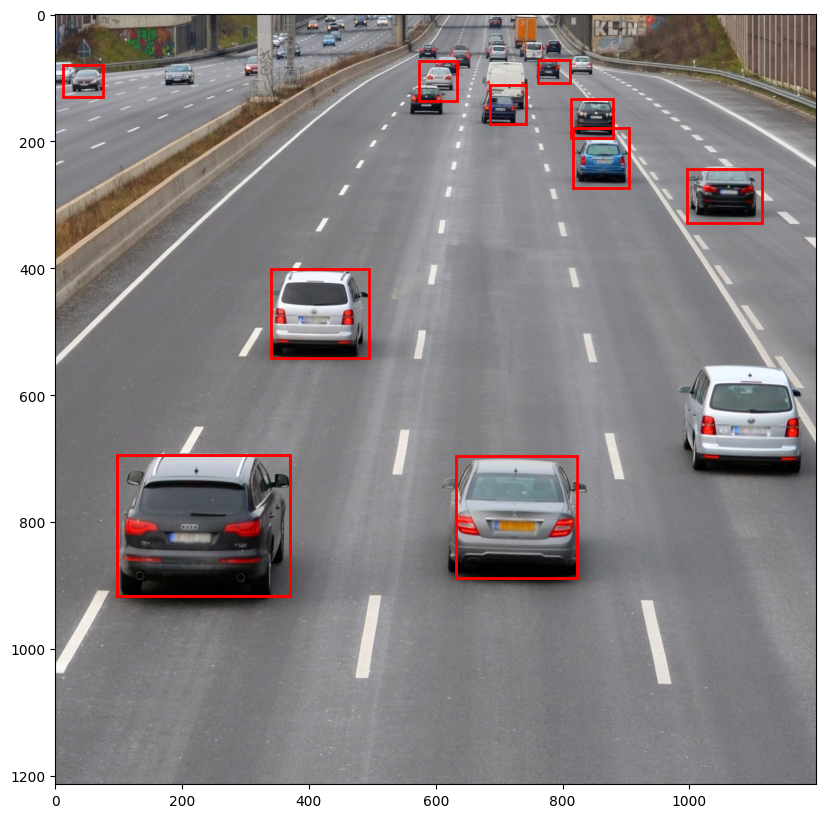

In [54]:
GenerarReconocimiento("img_car.png")